<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/Logistic_Regression_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                           roc_auc_score, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [53]:
df = pd.read_csv('diabetes (1).csv')

In [54]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [55]:
print("\nData Info:")
df.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [56]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [57]:
# Check for zero values
print("Zero values per column:")
print((df == 0).sum())

Zero values per column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [58]:
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [59]:
df_clean = df.copy()
for col in zero_invalid_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("\nAfter cleaning - Missing values:")
print(df_clean.isnull().sum())


After cleaning - Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


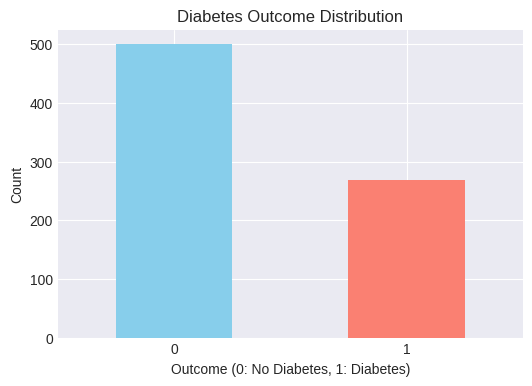

In [60]:
#Exploratory Data Analysis (EDA)
plt.figure(figsize=(6, 4))
df_clean['Outcome'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

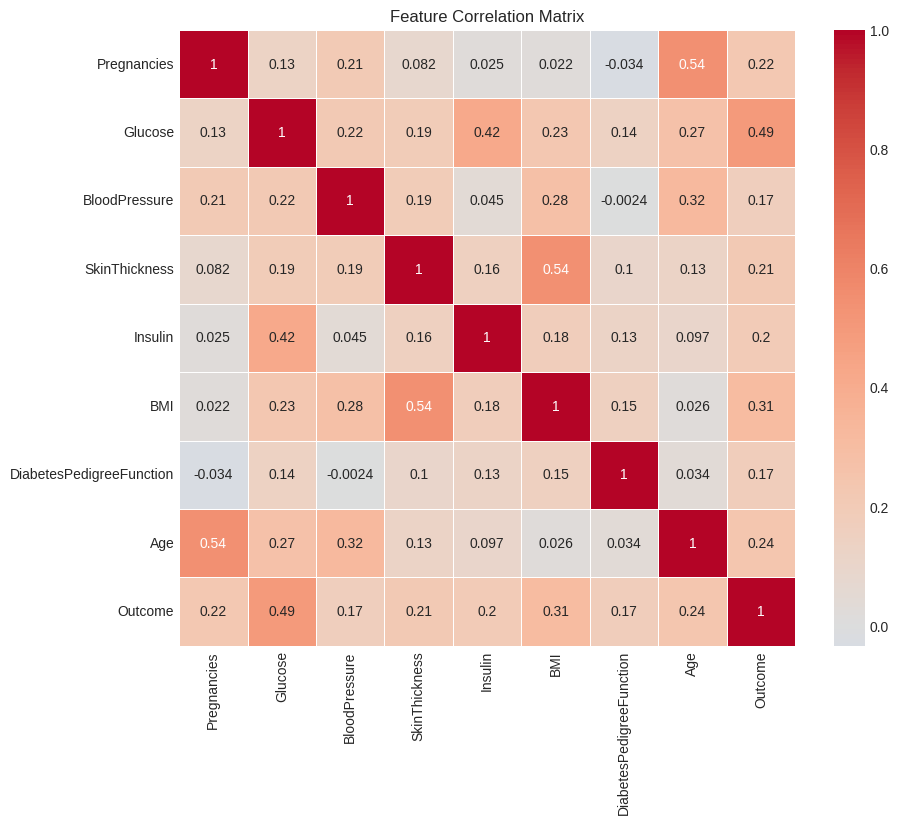

In [61]:
#Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

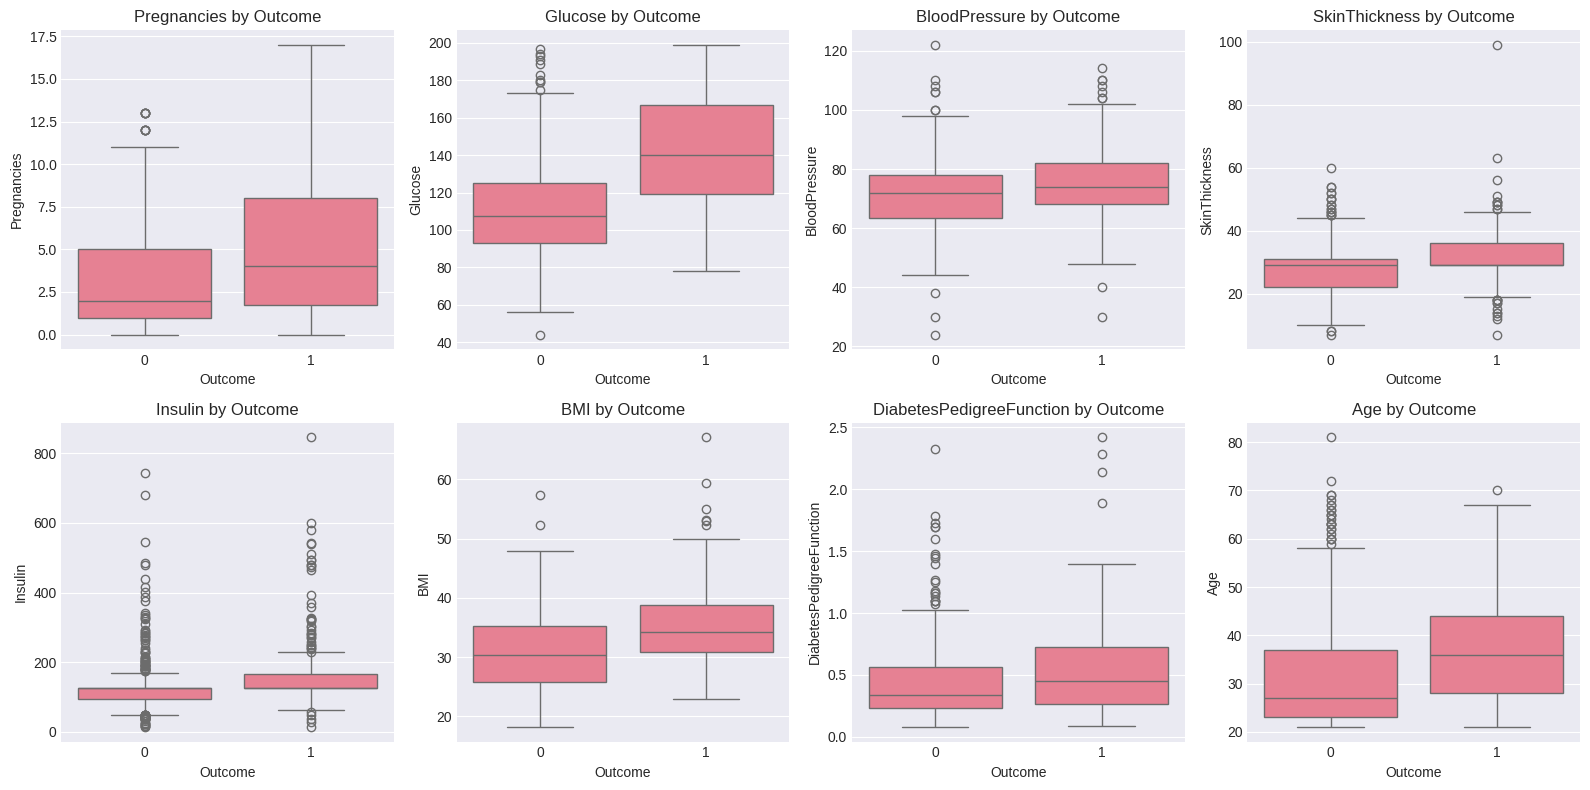

In [62]:
#Feature Distributions by Outcome
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(df_clean.columns[:-1]):
    sns.boxplot(x='Outcome', y=col, data=df_clean, ax=axes[idx])
    axes[idx].set_title(f'{col} by Outcome')

plt.tight_layout()
plt.show()

In [63]:
#Feature Engineering and Scaling

# Separate features and target
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']


In [64]:
# Feature names for later use
feature_names = X.columns.tolist()

In [65]:
# Train-Test Split (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training set class distribution:\n{y_train.value_counts(normalize=True)}")

Training set size: (614, 8)
Test set size: (154, 8)
Training set class distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


In [66]:
# Feature Scaling (essential for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
# Convert to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

Training Logistic Regression...


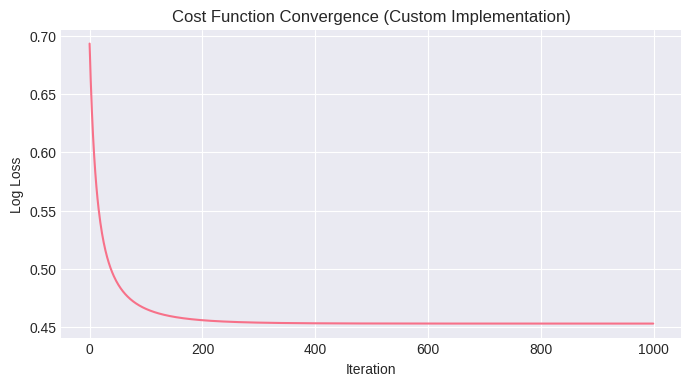

Custom Model Accuracy: 0.7078


In [68]:
#Logistic Regression Implementation

class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for i in range(self.n_iterations):
            # Linear model
            linear_model = np.dot(X, self.weights) + self.bias

            # Sigmoid
            y_predicted = self.sigmoid(linear_model)

            # Cost function (Log Loss)
            cost = (-1/n_samples) * np.sum(y * np.log(y_predicted + 1e-15) +
                                           (1-y) * np.log(1 - y_predicted + 1e-15))
            self.cost_history.append(cost)

            # Gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)

            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

        return self

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Train custom model
print("Training Logistic Regression...")
custom_model = CustomLogisticRegression(learning_rate=0.1, n_iterations=1000)
custom_model.fit(X_train_scaled.values, y_train.values)

# Plot cost function convergence
plt.figure(figsize=(8, 4))
plt.plot(custom_model.cost_history)
plt.title('Cost Function Convergence (Custom Implementation)')
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.grid(True)
plt.show()

# Evaluate custom model
custom_pred = custom_model.predict(X_test_scaled.values)
print(f"Custom Model Accuracy: {accuracy_score(y_test, custom_pred):.4f}")

In [69]:
# Initialize model with balanced class weights (dataset is imbalanced)
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

In [70]:
# Hyperparameter Grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}


In [71]:
# Grid Search with Cross-Validation
print("Performing Grid Search (this may take a moment)...")
grid_search = GridSearchCV(
    log_reg, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

Performing Grid Search (this may take a moment)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation ROC-AUC: 0.8423


In [72]:
# Best model
best_model = grid_search.best_estimator_

In [73]:
#Model Evaluation and Diagnostics

# Predictions
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]


In [74]:
# Metrics
print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

MODEL PERFORMANCE METRICS
Accuracy: 0.7208
ROC-AUC Score: 0.8106

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.82      0.73      0.77       100
    Diabetes       0.58      0.70      0.64        54

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154



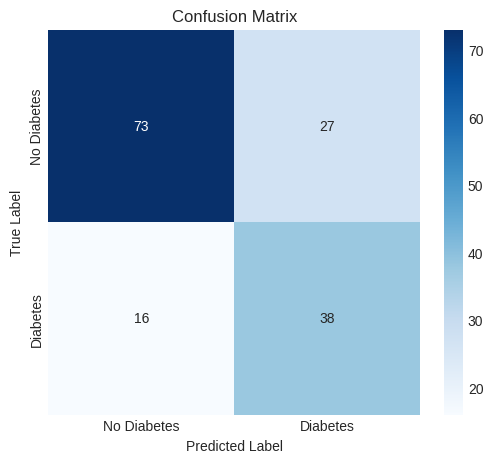

In [75]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
          xticklabels=['No Diabetes', 'Diabetes'],
          yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

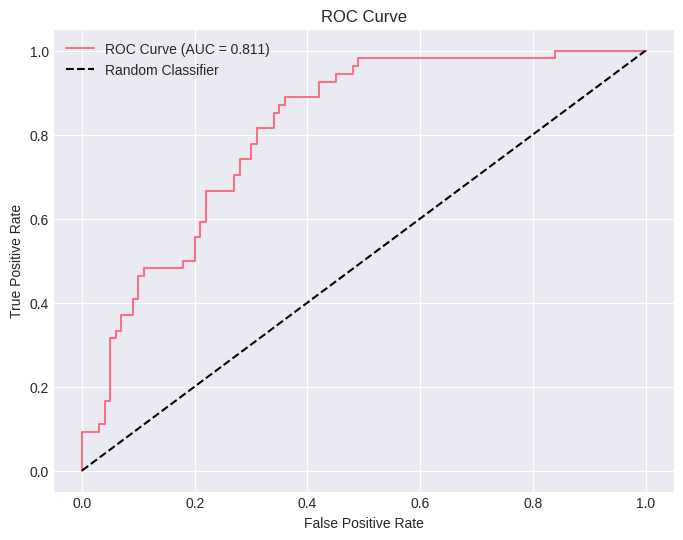

In [76]:
# ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

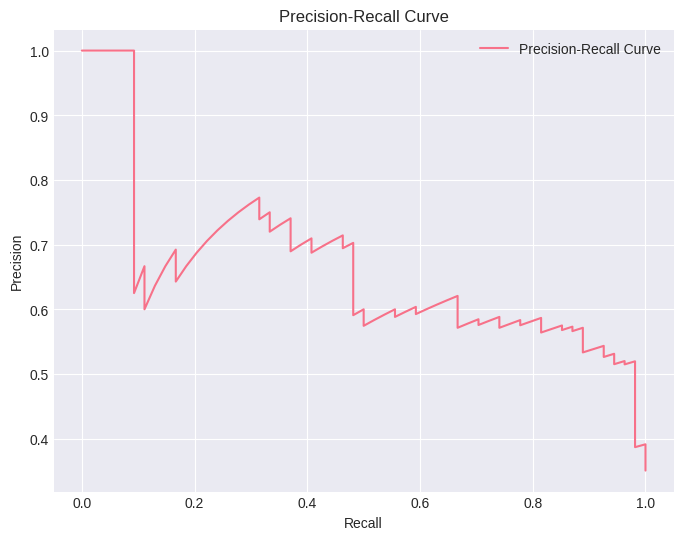

In [77]:
# Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

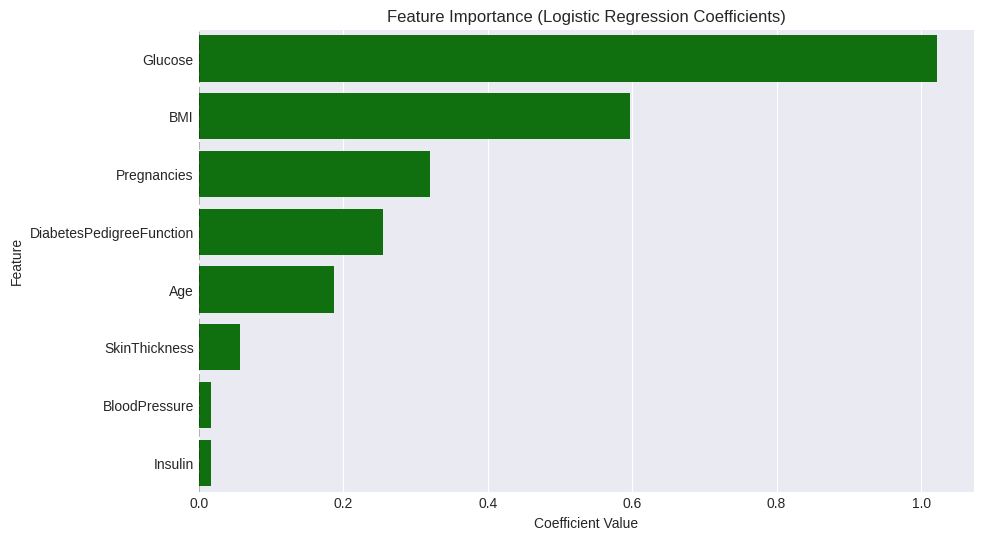

Coefficients Interpretation:
                    Feature  Coefficient  Abs_Coefficient
1                   Glucose     1.021699         1.021699
5                       BMI     0.597110         0.597110
0               Pregnancies     0.319821         0.319821
6  DiabetesPedigreeFunction     0.255472         0.255472
7                       Age     0.187569         0.187569
3             SkinThickness     0.057422         0.057422
2             BloodPressure     0.017484         0.017484
4                   Insulin     0.016441         0.016441

Note: Positive coefficients increase diabetes probability, negative decrease it.


In [78]:
#Feature Importance Analysis

# Coefficients represent log-odds
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_model.coef_[0],
    'Abs_Coefficient': np.abs(best_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, y='Feature', x='Coefficient',
            palette=['red' if x < 0 else 'green' for x in coefficients['Coefficient']])
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.show()

print("Coefficients Interpretation:")
print(coefficients)
print("\nNote: Positive coefficients increase diabetes probability, negative decrease it.")


In [79]:
#Cross-Validation Robustness Check

cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"Cross-Validation ROC-AUC Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation ROC-AUC Scores: [0.82674419 0.85494186 0.7994186  0.86656977 0.8639881 ]
Mean CV Score: 0.8423 (+/- 0.0514)


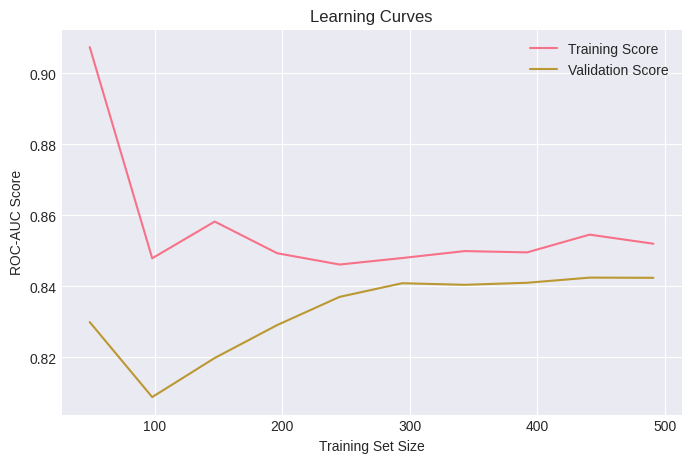

In [80]:
# Learning Curve analysis
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='roc_auc'
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curves')
plt.legend()
plt.grid(True)
plt.show()